In [13]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.b import Model_b
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
a = Model_b()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

[[[ 0.         11.86683685 14.22655837 16.9100614  19.65392336
   22.27344913 27.07097414]]]


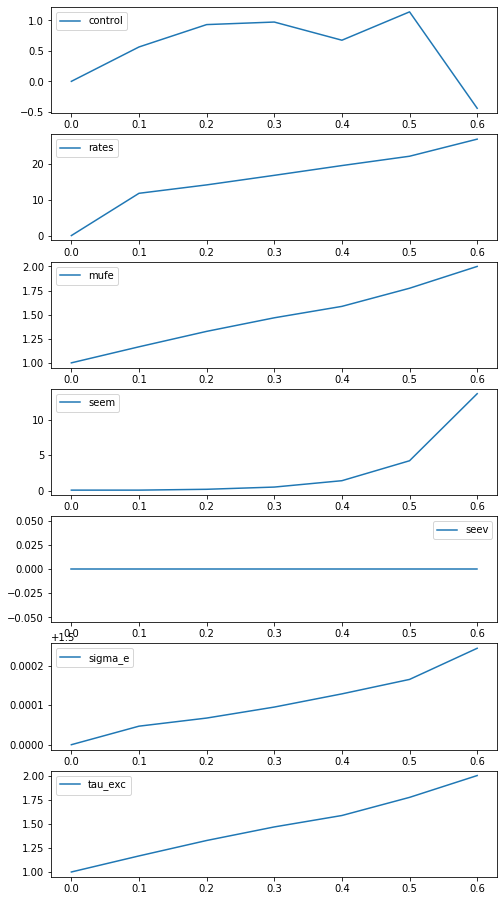

In [107]:
dur = 0.6

a.params.duration = dur
a.params.ext_exc_current = 2.

target = a.getZeroTarget()
control1 = a.getZeroControl()

control1[0,0,5] += 1.
control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.state["rates_exc"][0,:]

fig, axes = plt.subplots(7, figsize=(8, 16))
axes[0].plot(a.t, control1[0,0,:], label="control")
axes[1].plot(a.t, a.state["rates_exc"][0,:], label="rates")
axes[2].plot(a.t, a.state["mufe"][0,:], label="mufe")
axes[3].plot(a.t, a.state["seem"][0,:], label="seem")
axes[4].plot(a.t, a.state["seev"][0,:], label="seev")
axes[5].plot(a.t, a.state["sigmae_f"][0,:], label="sigma_e")
axes[6].plot(a.t, a.state["tau_exc"][0,:], label="tau_exc")
for i in range(7):
    axes[i].legend()

print(target)

In [109]:
max_cntrl = 100. * 5.
start_step = 100.
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init, a.params.seem_init, a.params.seev_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
#control2 += 1.

max_it = 80

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
RUN  0 , total integrated cost =  3.860058606472699
RUN  1 , total integrated cost =  0.3624112637785116
RUN  2 , total integrated cost =  0.3284645048691467
RUN  3 , total integrated cost =  0.32812343477313305
RUN  4 , total integrated cost =  0.3279054187664798
RUN  5 , total integrated cost =  0.32776565149424924
RUN  6 , total integrated cost =  0.3276751313445892
RUN  7 , total integrated cost =  0.3276165556389356
RUN  8 , total integrated cost =  0.3275782985195651
RUN  9 , total integrated cost =  0.3275533180193414
RUN  10 , total integrated cost =  0.327537025067624
RUN  11 , total integrated cost =  0.32752643411344035
RUN  12 , total integrated cost =  0.3275195347102782
RUN  13 , total integrated cost =  0.3275150044171824
RUN  14 , total integrated cost =  0.32751203826324893
RUN  15 , total integrated cost =  0.3275100927006937
RUN  16 , total integrated cost =  0.32750881502258267
RUN  17 , total integrated cost =  0.32750797830105877
RUN  18 , total in

[[[0.         0.01450721 0.02669513 0.06151853 0.14928216 0.36989719
   0.        ]]]


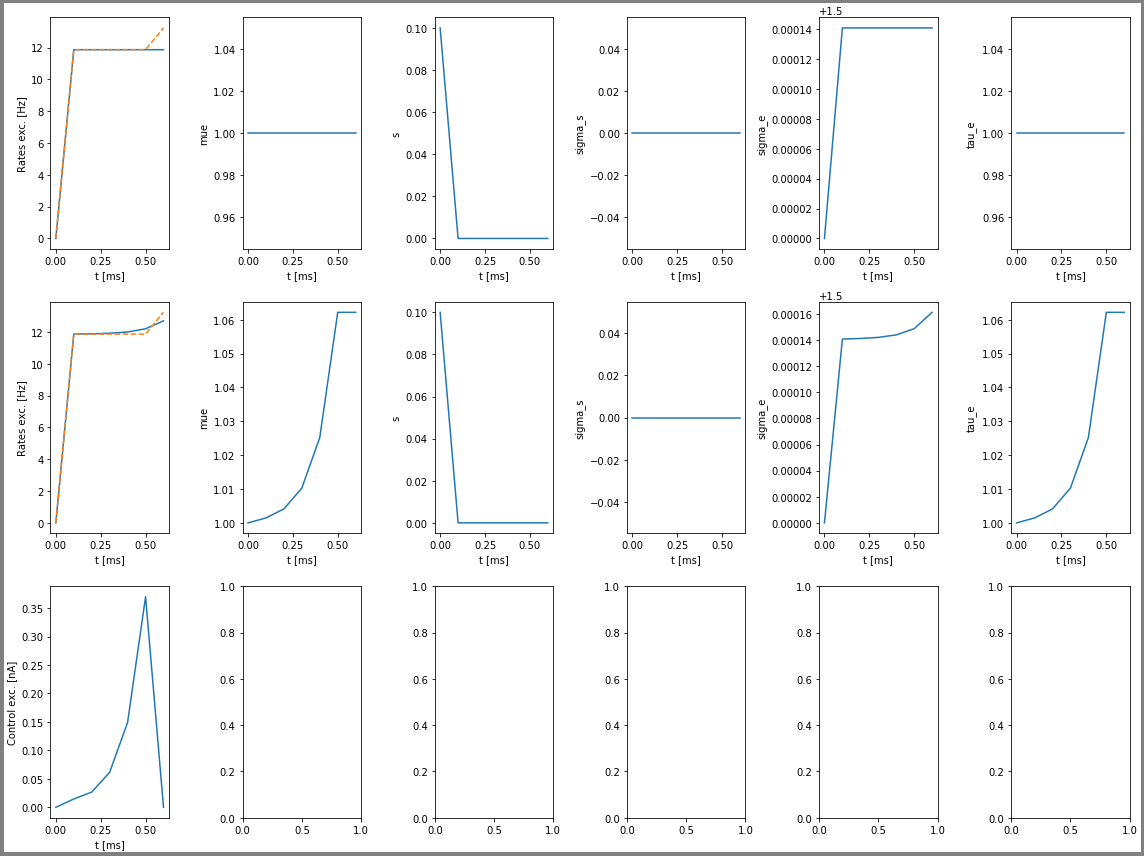

In [55]:
"""
RUN  80 , total integrated cost =  1.3734613222429528
Improved over  80  iterations by  95.35955938543219  percent.
final gradient =  [[[0.00000000e+00 2.08495165e-06 1.65800624e-06 1.82331646e-06
   1.33923364e-06 7.80983380e-07 0.00000000e+00]]]
"""
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [56]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 40

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  0.0935630060319051
RUN  1 , total integrated cost:  0.05472064502546635
RUN  2 , total integrated cost:  0.03777724715929252
RUN  3 , total integrated cost:  0.03741873852456126
RUN  4 , total integrated cost:  0.03728689277253167
change helped, counter =  1
RUN  5 , total integrated cost:  0.03721814921002713
RUN  6 , total integrated cost:  0.03719983073089826
change helped, counter =  1
RUN  7 , total integrated cost:  0.03719664279085276
RUN  8 , total integrated cost:  0.03719623092351791
change helped, counter =  1
change helped, counter =  3
RUN  9 , total integrated cost:  0.03719611440748056
change helped, counter =  1
RUN  10 , total integrated cost:  0.03719606126685091
RUN  11 , total integrated cost:  0.03719603117574653
change helped, counter =  2
change helped, counter =  2
RUN  12 , total integrated cost:  0.037196020250788824
change helped, counter =  2
change helped, counter =  3
change helped, counter =  3
RUN  13 , tot

[[[0.         0.01448131 0.02668994 0.06152288 0.14931941 0.36993491
   0.        ]]]


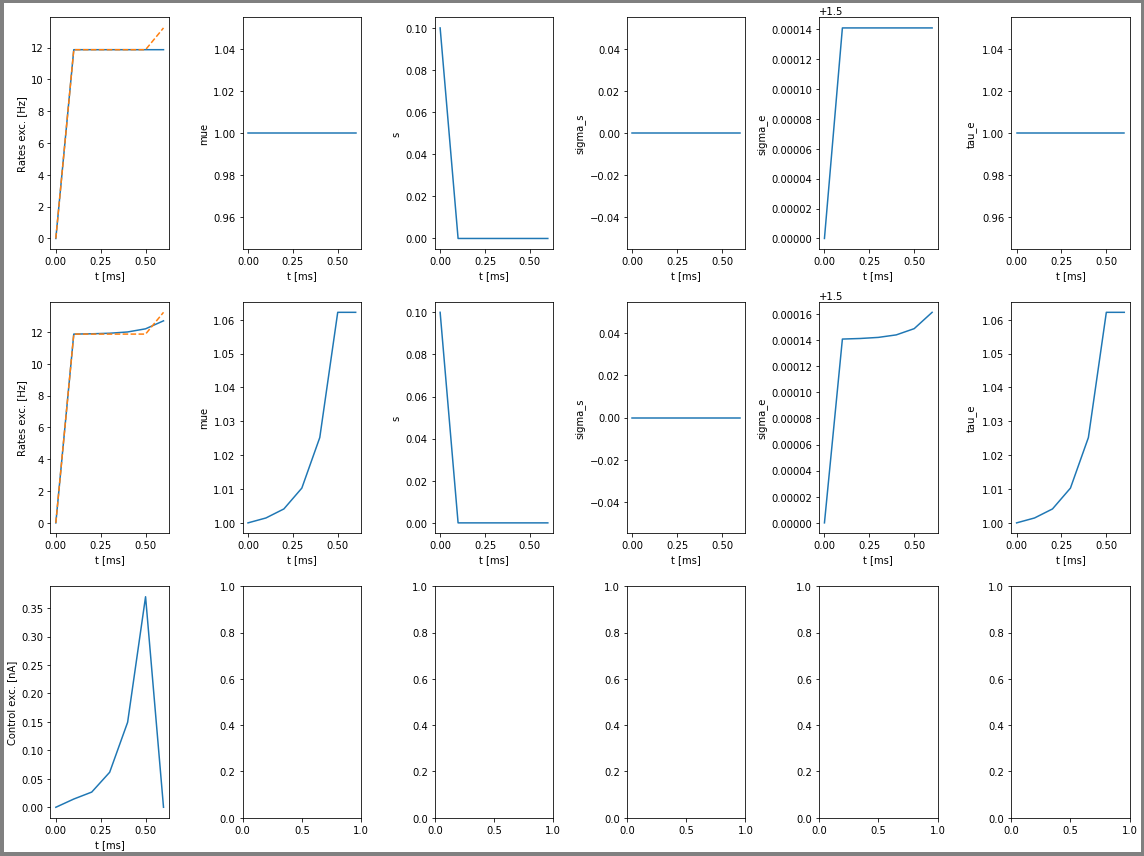

In [57]:
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

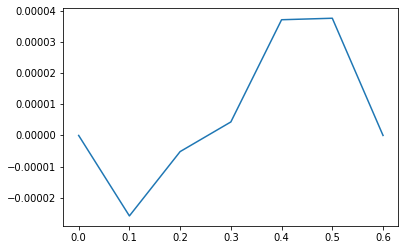

In [58]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

(350, 64, 2)


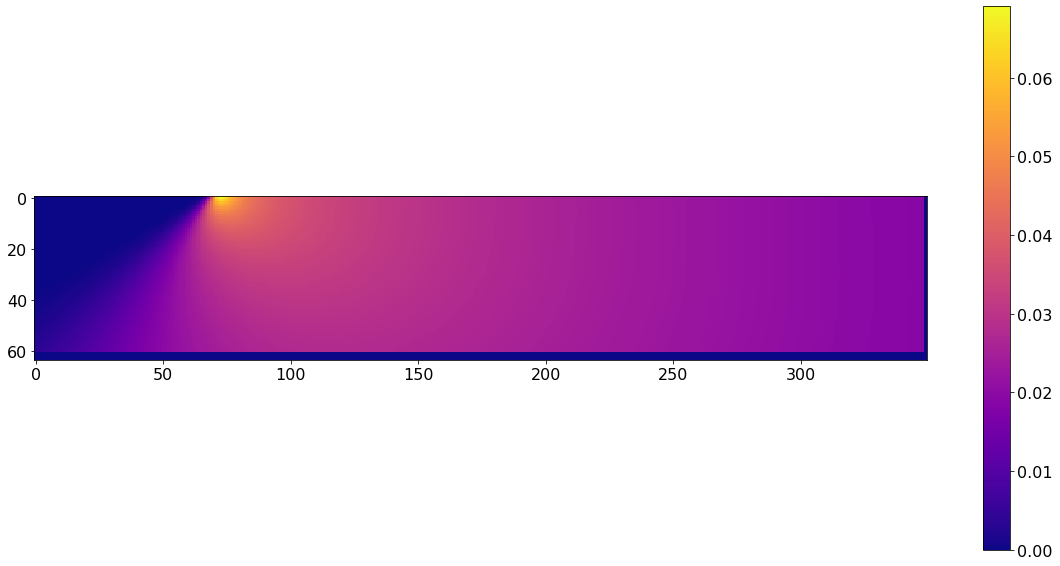

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


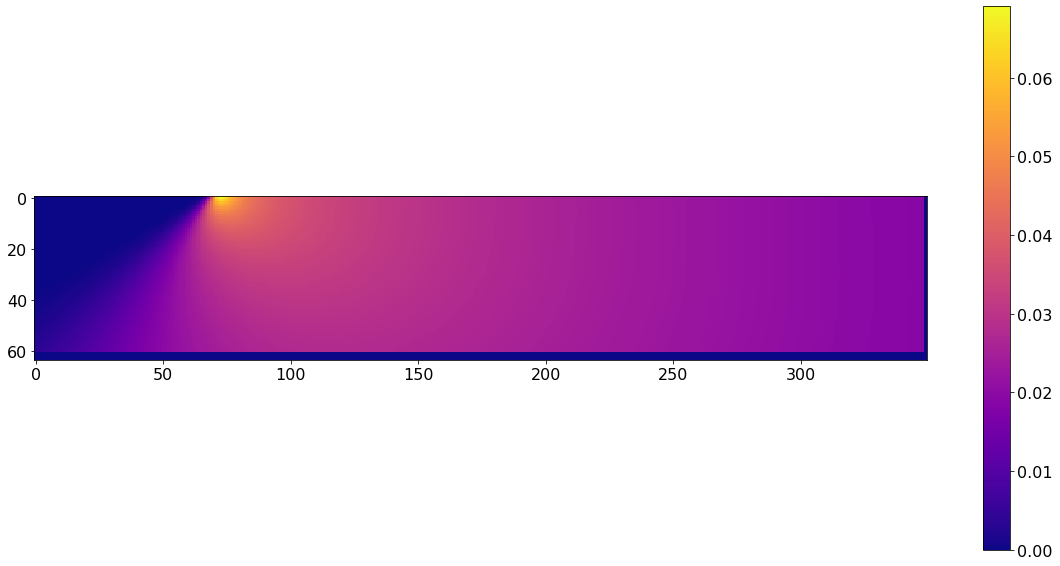

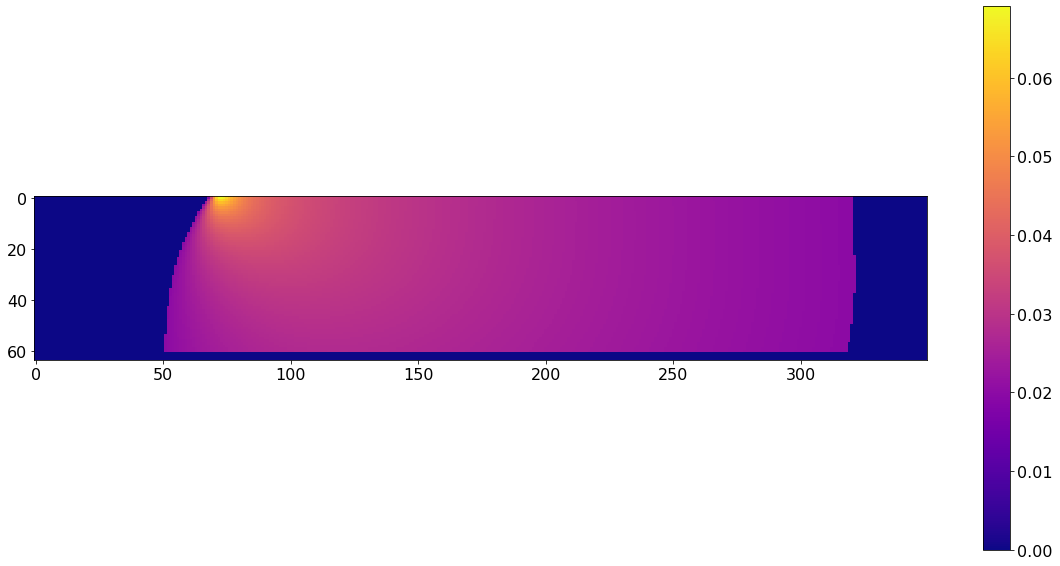

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()